# 🔧 Hyperparameter Tuning — XGBoost Regressor

This notebook performs systematic hyperparameter tuning on the **XGBRegressor** model for used car price prediction.

### Tuning Strategy

We use a **two-phase approach** for efficient search:

| Phase | Method | Purpose |
|-------|--------|---------|
| 1 | **RandomizedSearchCV** | Broad exploration of all 7 hyperparameters |
| 2 | **GridSearchCV** | Fine-tune only the **top 3 most impactful** parameters |

### Parameters to Tune

| Parameter | Description |
|-----------|-------------|
| `n_estimators` | Number of boosting rounds |
| `max_depth` | Maximum tree depth |
| `learning_rate` | Step size shrinkage (eta) |
| `subsample` | Row sampling ratio per tree |
| `colsample_bytree` | Column sampling ratio per tree |
| `min_child_weight` | Minimum sum of instance weight in a child node |
| `gamma` | Minimum loss reduction to make a further partition |

## 1 · Imports & Configuration

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV,
    cross_val_score
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries imported successfully.')

All libraries imported successfully.


## 2 · Load Data & Train-Test Split

Using the same feature-engineered dataset and split strategy as the Baseline notebook for a fair comparison.

In [13]:
df = pd.read_csv('feature_engineered_car_data.csv')
print(f'Dataset shape: {df.shape}')
print(f'Null values  : {df.isnull().sum().sum()}')

TARGET = 'listed_price'
drop_cols = [TARGET, 'discountValue']

X = df.drop(columns=drop_cols)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f'\nFeatures     : {X.shape[1]}')
print(f'Training set : {X_train.shape[0]:,} samples')
print(f'Test set     : {X_test.shape[0]:,} samples')

Dataset shape: (37750, 83)
Null values  : 0

Features     : 81
Training set : 30,200 samples
Test set     : 7,550 samples


## 3 · Baseline XGBoost (Before Tuning)

Establishing the **baseline performance** using the default hyperparameters from the Baseline_Models notebook.

In [14]:
baseline_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0
)

baseline_xgb.fit(X_train, y_train)

y_pred_baseline = baseline_xgb.predict(X_test)

baseline_mae  = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2   = r2_score(y_test, y_pred_baseline)

print('=' * 55)
print('  BASELINE XGBoost Performance (Test Set)')
print('=' * 55)
print(f'  MAE  : {baseline_mae:>15,.2f}')
print(f'  RMSE : {baseline_rmse:>15,.2f}')
print(f'  R2   : {baseline_r2:>15.4f}')
print('=' * 55)

  BASELINE XGBoost Performance (Test Set)
  MAE  :       55,064.50
  RMSE :       85,433.89
  R2   :          0.9647


## 4 · Evaluation Helper

In [15]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train-set and test-set evaluation with MAE, RMSE, R2."""
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    
    results = {
        'Model': name,
        'Train MAE' : mean_absolute_error(y_tr, y_pred_tr),
        'Train RMSE': np.sqrt(mean_squared_error(y_tr, y_pred_tr)),
        'Train R2'  : r2_score(y_tr, y_pred_tr),
        'Test MAE'  : mean_absolute_error(y_te, y_pred_te),
        'Test RMSE' : np.sqrt(mean_squared_error(y_te, y_pred_te)),
        'Test R2'   : r2_score(y_te, y_pred_te),
    }
    return results, y_pred_te

print('Helper function defined.')

Helper function defined.


## 5 · Phase 1 — RandomizedSearchCV (Broad Exploration)

We use a **compact but well-spaced parameter grid** that covers the effective range while avoiding
computationally expensive outlier combinations.

> **Optimized for speed:** 50 iterations × 3-fold CV = 150 fits.

### 5.1 · Define Parameter Distributions

In [16]:
param_distributions = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [4, 6, 8, 10],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'subsample'        : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9],
    'min_child_weight' : [1, 5, 10, 20],
    'gamma'            : [0, 0.1, 0.5, 1.0],
}

total_combos = 1
for v in param_distributions.values():
    total_combos *= len(v)
print(f'Total possible combinations: {total_combos:,}')
print(f'We will sample 50 random combinations with 3-fold CV = 150 fits.')

Total possible combinations: 16,384
We will sample 50 random combinations with 3-fold CV = 150 fits.


### 5.2 · Run RandomizedSearchCV

In [17]:
xgb_random = XGBRegressor(
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0
)

random_search = RandomizedSearchCV(
    estimator=xgb_random,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print('Starting RandomizedSearchCV (50 iterations x 3-fold CV = 150 fits)...')
print()

start_time = time.time()
random_search.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f'\nCompleted in {elapsed/60:.1f} minutes')

Starting RandomizedSearchCV (50 iterations x 3-fold CV = 150 fits)...

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Completed in 7.4 minutes


### 5.3 · Phase 1 Results

In [18]:
print('=' * 60)
print('  PHASE 1 - Best Parameters (RandomizedSearchCV)')
print('=' * 60)

best_params_phase1 = random_search.best_params_
for param, value in sorted(best_params_phase1.items()):
    print(f'  {param:20s} : {value}')

print(f'\n  Best CV MAE : {-random_search.best_score_:,.2f}')
print('=' * 60)

  PHASE 1 - Best Parameters (RandomizedSearchCV)
  colsample_bytree     : 0.9
  gamma                : 1.0
  learning_rate        : 0.05
  max_depth            : 8
  min_child_weight     : 5
  n_estimators         : 500
  subsample            : 0.7

  Best CV MAE : 54,650.26


In [19]:
# Detailed CV results
cv_results_phase1 = pd.DataFrame(random_search.cv_results_)
cv_results_phase1 = cv_results_phase1.sort_values('rank_test_score')

# Show top 10 configurations
top10_cols = ['rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score']
param_cols = [c for c in cv_results_phase1.columns if c.startswith('param_')]
display_cols = top10_cols + param_cols

print('Top 10 Configurations from Phase 1:\n')
cv_results_phase1[display_cols].head(10)

Top 10 Configurations from Phase 1:



,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_gamma,param_colsample_bytree
25,1,-54650.259898,517.470926,-27274.076957,0.7,500,5,8,0.05,1.0,0.9
41,2,-54806.835327,556.195160,-27876.628224,0.8,500,20,10,0.05,0.5,0.6
24,3,-55159.931117,490.093876,-25713.171620,0.9,300,10,10,0.05,0.1,0.9
39,4,-55185.635206,595.800149,-22062.316437,0.8,300,5,10,0.05,0.0,0.8
13,5,-55187.387327,565.093339,-17705.938098,0.8,300,1,10,0.05,0.1,0.7
32,6,-55199.413479,670.877161,-17005.851712,0.9,300,1,10,0.05,0.0,0.7
44,7,-55313.388407,568.162718,-20808.477981,0.9,300,5,10,0.05,1.0,0.9
18,8,-55479.380067,540.279314,-29835.369532,0.9,200,5,8,0.10,1.0,0.9
45,9,-55507.835236,441.716121,-32951.950332,0.9,300,20,8,0.10,0.5,0.6
20,10,-55541.150045,383.849540,-32540.276556,0.7,200,5,8,0.10,0.1,0.6


### 5.4 · Phase 1 — Parameter Impact Visualizations

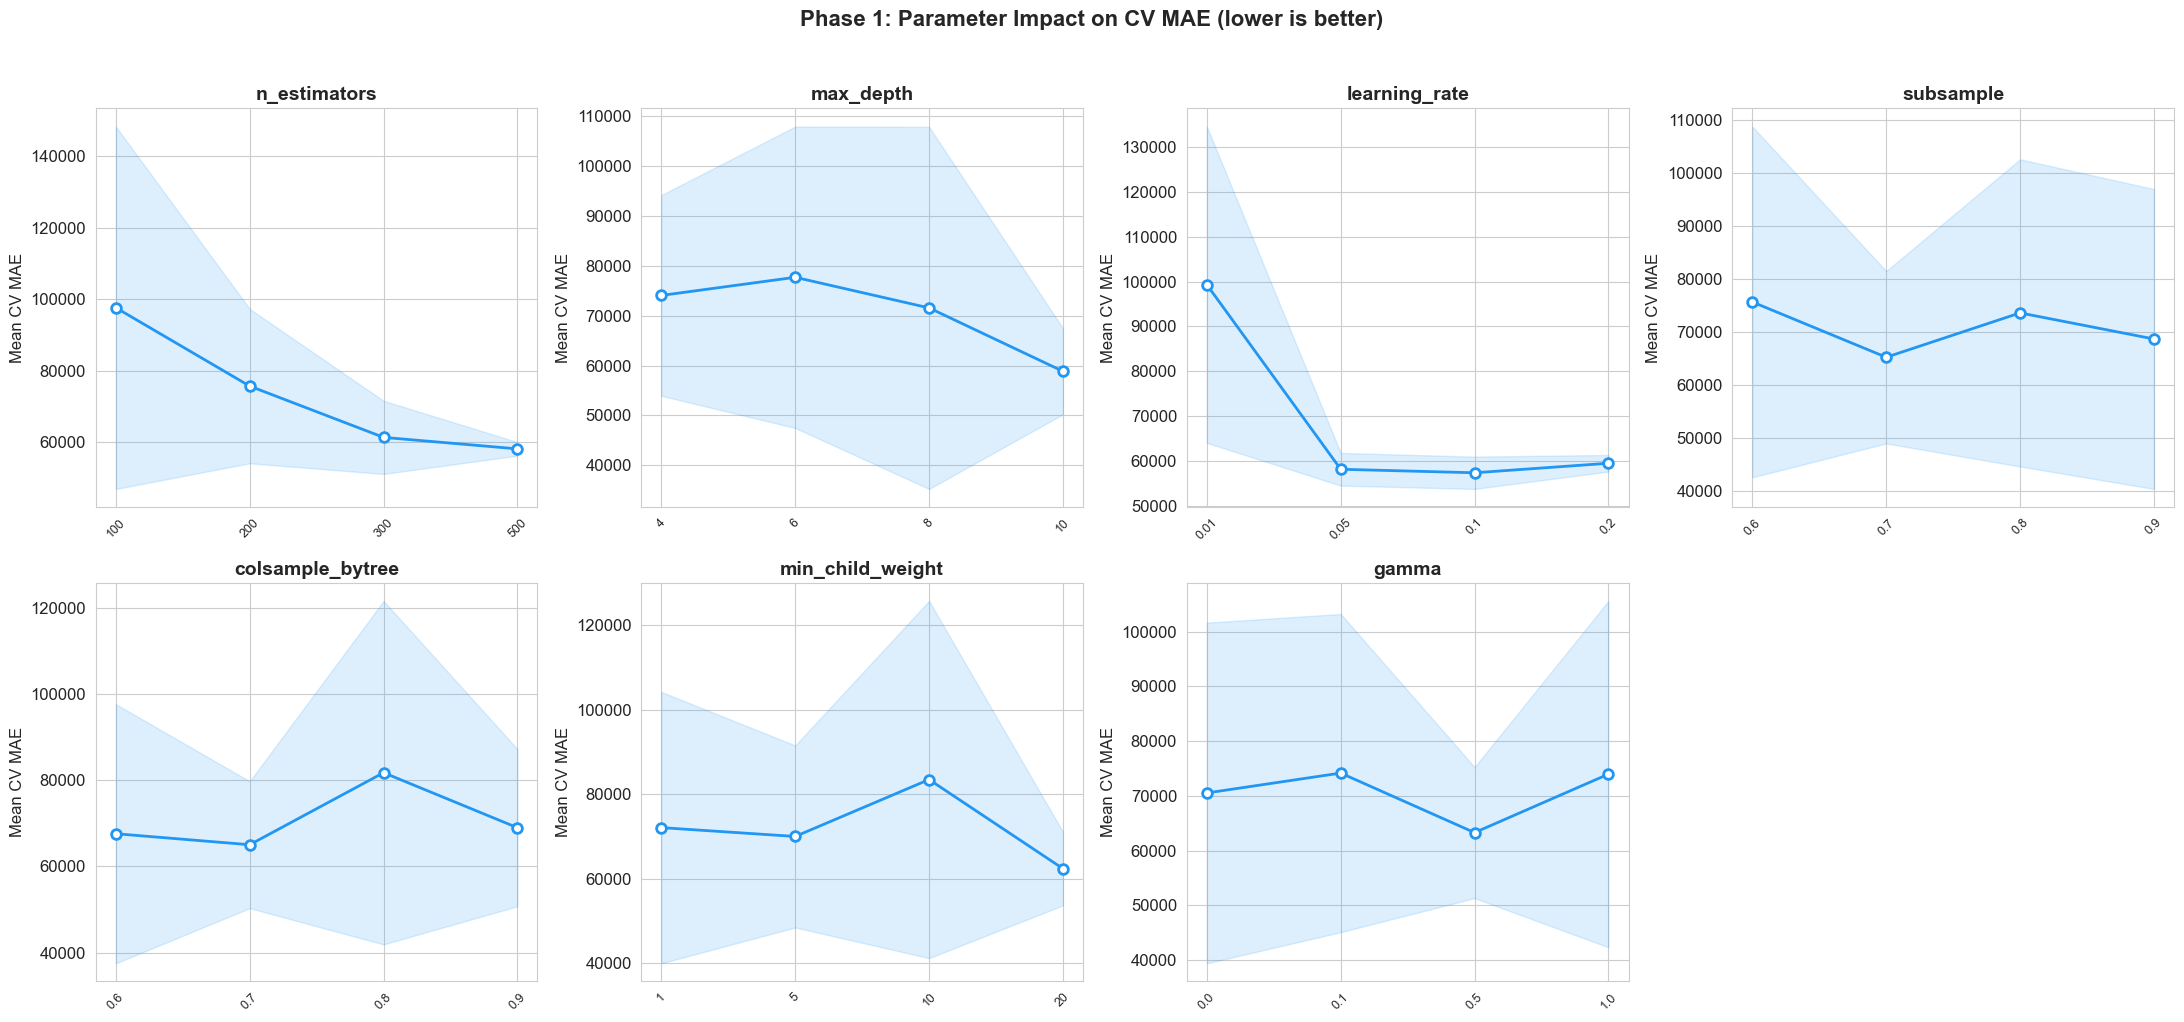

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

params_to_plot = list(param_distributions.keys())

for idx, param in enumerate(params_to_plot):
    param_col = f'param_{param}'
    ax = axes[idx]
    
    grouped = cv_results_phase1.groupby(param_col)['mean_test_score'].agg(['mean', 'std'])
    grouped['mean'] = -grouped['mean']
    grouped = grouped.sort_index()
    
    ax.plot(range(len(grouped)), grouped['mean'], 'o-', color='#2196F3', 
            linewidth=2, markersize=7, markerfacecolor='white', markeredgewidth=2)
    ax.fill_between(range(len(grouped)), 
                    grouped['mean'] - grouped['std'], 
                    grouped['mean'] + grouped['std'], 
                    alpha=0.15, color='#2196F3')
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([str(x) for x in grouped.index], rotation=45, fontsize=9)
    ax.set_title(param, fontweight='bold')
    ax.set_ylabel('Mean CV MAE')

axes[7].set_visible(False)

plt.suptitle('Phase 1: Parameter Impact on CV MAE (lower is better)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.5 · Identify Top 3 Most Impactful Parameters

We measure each parameter's impact by the **variance in mean CV score** across its values.  
Parameters with higher variance have more influence on model performance.  
Only these top 3 will be fine-tuned in Phase 2 — the rest are locked to Phase 1's best values.

In [21]:
# Compute impact score: variance of mean CV MAE across each param's values
param_impact = {}
for param in param_distributions.keys():
    param_col = f'param_{param}'
    grouped = cv_results_phase1.groupby(param_col)['mean_test_score'].mean()
    param_impact[param] = grouped.var()

impact_df = pd.DataFrame({
    'Parameter': list(param_impact.keys()),
    'Impact Score (variance)': list(param_impact.values())
}).sort_values('Impact Score (variance)', ascending=False).reset_index(drop=True)

impact_df.index = impact_df.index + 1
impact_df.index.name = 'Rank'

# Select top 3
TOP_N = 3
top_params = impact_df['Parameter'].head(TOP_N).tolist()

print('Parameter Impact Ranking:')
print('=' * 50)
print(impact_df.to_string())
print('=' * 50)
print(f'\nTop {TOP_N} parameters selected for Phase 2 fine-tuning:')
for p in top_params:
    print(f'  -> {p}')
print(f'\nRemaining parameters will be fixed at Phase 1 best values.')

Parameter Impact Ranking:
             Parameter  Impact Score (variance)
Rank                                           
1        learning_rate             4.202033e+08
2         n_estimators             3.228408e+08
3     min_child_weight             7.611423e+07
4            max_depth             6.701502e+07
5     colsample_bytree             5.559579e+07
6                gamma             2.586136e+07
7            subsample             2.234475e+07

Top 3 parameters selected for Phase 2 fine-tuning:
  -> learning_rate
  -> n_estimators
  -> min_child_weight

Remaining parameters will be fixed at Phase 1 best values.


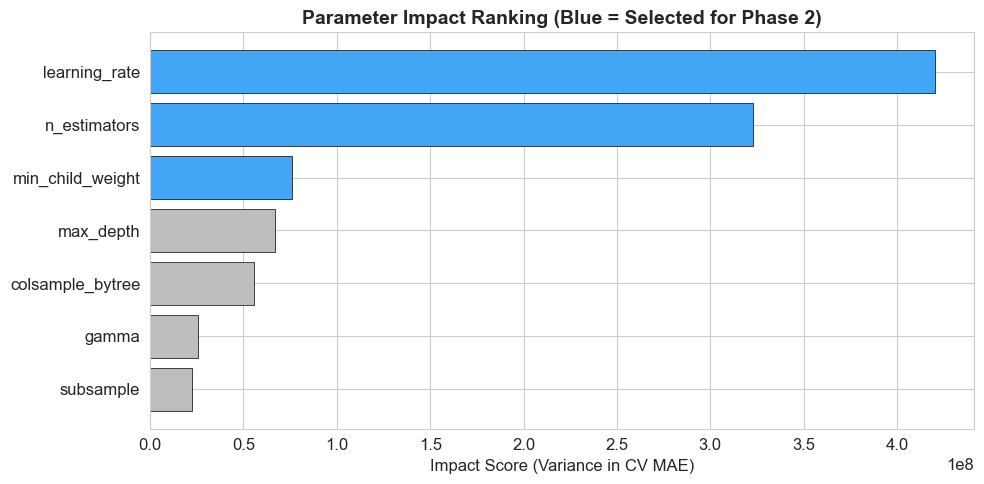

In [22]:
# Visualize parameter impact
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#42A5F5' if p in top_params else '#BDBDBD' for p in impact_df['Parameter']]
bars = ax.barh(impact_df['Parameter'][::-1], 
               impact_df['Impact Score (variance)'][::-1], 
               color=colors[::-1], edgecolor='black', linewidth=0.5)

ax.set_xlabel('Impact Score (Variance in CV MAE)')
ax.set_title('Parameter Impact Ranking (Blue = Selected for Phase 2)', fontweight='bold')
plt.tight_layout()
plt.show()

## 6 · Phase 2 — GridSearchCV (Fine-Tuning Top 3 Parameters)

We **only fine-tune the top 3 most impactful parameters** from Phase 1.  
The remaining 4 parameters are **fixed at their Phase 1 best values**.  
This keeps the grid small (~50–150 combinations) and finishes in **2–3 minutes**.

### 6.1 · Build Fine-Tuning Grid (Top 3 Only)

In [23]:
def build_fine_grid_top_n(best_params, distributions, top_params):
    """Build a narrow grid for only the top N most impactful parameters."""
    fine_grid = {}
    
    for param in top_params:
        best_val = best_params[param]
        candidates = sorted(distributions[param])
        best_idx = candidates.index(best_val)
        
        # Take best value and immediate neighbors
        start = max(0, best_idx - 1)
        end   = min(len(candidates), best_idx + 2)
        fine_grid[param] = candidates[start:end]
        
        # For continuous params, add midpoints between neighbors
        if param in ['learning_rate', 'subsample', 'colsample_bytree', 'gamma']:
            extended = list(fine_grid[param])
            new_vals = []
            for i in range(len(extended) - 1):
                mid = round((extended[i] + extended[i+1]) / 2, 4)
                if mid not in extended:
                    new_vals.append(mid)
            extended.extend(new_vals)
            fine_grid[param] = sorted(set(extended))
    
    return fine_grid

fine_param_grid = build_fine_grid_top_n(best_params_phase1, param_distributions, top_params)

# Fixed params = Phase 1 best values for the non-top parameters
fixed_params = {p: v for p, v in best_params_phase1.items() if p not in top_params}

print('FINE-TUNING GRID (Top 3 parameters):')
print('-' * 55)
total = 1
for param, values in fine_param_grid.items():
    print(f'  [TUNE]  {param:20s} : {values}')
    total *= len(values)
print()
for param, value in fixed_params.items():
    print(f'  [FIXED] {param:20s} : {value}')
print('-' * 55)
print(f'Grid combinations  : {total:,}')
print(f'Total fits (x3 CV) : {total * 3:,}')

FINE-TUNING GRID (Top 3 parameters):
-------------------------------------------------------
  [TUNE]  learning_rate        : [0.01, 0.03, 0.05, 0.075, 0.1]
  [TUNE]  n_estimators         : [300, 500]
  [TUNE]  min_child_weight     : [1, 5, 10]

  [FIXED] subsample            : 0.7
  [FIXED] max_depth            : 8
  [FIXED] gamma                : 1.0
  [FIXED] colsample_bytree     : 0.9
-------------------------------------------------------
Grid combinations  : 30
Total fits (x3 CV) : 90


### 6.2 · Run GridSearchCV

In [24]:
xgb_grid = XGBRegressor(
    **fixed_params,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0
)

grid_search = GridSearchCV(
    estimator=xgb_grid,
    param_grid=fine_param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print(f'Starting GridSearchCV ({total} combinations x 3-fold CV = {total * 3} fits)...')
print()

start_time = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f'\nCompleted in {elapsed/60:.1f} minutes')

Starting GridSearchCV (30 combinations x 3-fold CV = 90 fits)...

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Completed in 7.0 minutes


### 6.3 · Phase 2 Results

In [25]:
print('=' * 60)
print('  PHASE 2 - Best Parameters (GridSearchCV)')
print('=' * 60)

# Merge grid search best params with fixed params for complete picture
best_params_final = {**fixed_params, **grid_search.best_params_}

for param, value in sorted(best_params_final.items()):
    tag = '[TUNED]' if param in top_params else '[FIXED]'
    print(f'  {tag:8s} {param:20s} : {value}')

print(f'\n  Best CV MAE : {-grid_search.best_score_:,.2f}')
print('=' * 60)

  PHASE 2 - Best Parameters (GridSearchCV)
  [FIXED]  colsample_bytree     : 0.9
  [FIXED]  gamma                : 1.0
  [TUNED]  learning_rate        : 0.03
  [FIXED]  max_depth            : 8
  [TUNED]  min_child_weight     : 1
  [TUNED]  n_estimators         : 500
  [FIXED]  subsample            : 0.7

  Best CV MAE : 54,447.40


In [26]:
# Detailed CV results from Phase 2
cv_results_phase2 = pd.DataFrame(grid_search.cv_results_)
cv_results_phase2 = cv_results_phase2.sort_values('rank_test_score')

top10_cols = ['rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score']
param_cols = [c for c in cv_results_phase2.columns if c.startswith('param_')]
display_cols = top10_cols + param_cols

print('Top 10 Configurations from Phase 2:\n')
cv_results_phase2[display_cols].head(10)

Top 10 Configurations from Phase 2:



,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_learning_rate,param_min_child_weight,param_n_estimators
7,1,-54447.401465,505.270041,-31451.214511,0.030,1,500
9,2,-54568.268796,491.865203,-33833.959227,0.030,5,500
13,3,-54648.420573,587.268527,-24361.289273,0.050,1,500
15,4,-54650.259898,517.470926,-27274.076957,0.050,5,500
11,5,-54751.058419,445.103554,-36300.888323,0.030,10,500
12,6,-54826.187894,593.628631,-31704.823053,0.050,1,300
14,7,-54867.246576,562.693462,-34141.844955,0.050,5,300
17,8,-54899.887286,448.595382,-30527.183302,0.050,10,500
16,9,-55094.813172,519.422354,-36570.112181,0.050,10,300
18,10,-55245.610321,436.733784,-26224.325728,0.075,1,300


## 7 · Evaluate Tuned Model on Test Set

In [27]:
# Build the final tuned model with all best params
tuned_xgb = XGBRegressor(
    **best_params_final,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0
)
tuned_xgb.fit(X_train, y_train)

# Evaluate baseline and tuned
baseline_results, y_pred_base = evaluate_model(
    'Baseline XGBoost', baseline_xgb, X_train, y_train, X_test, y_test
)
tuned_results, y_pred_tuned = evaluate_model(
    'Tuned XGBoost', tuned_xgb, X_train, y_train, X_test, y_test
)

comparison = pd.DataFrame([baseline_results, tuned_results]).set_index('Model')

# Add improvement row
improvement = {
    col: tuned_results[col] - baseline_results[col]
    for col in comparison.columns
}
improvement_pct = {
    col: ((tuned_results[col] - baseline_results[col]) / abs(baseline_results[col])) * 100
    for col in comparison.columns
}

comparison.loc['Improvement'] = improvement
comparison.loc['Improvement %'] = improvement_pct

print('\n' + '=' * 70)
print('  BASELINE vs TUNED XGBoost')
print('=' * 70)
comparison


  BASELINE vs TUNED XGBoost


,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
Model,,,,,,
Baseline XGBoost,27139.345553,37345.378868,0.993228,55064.498589,85433.893057,0.964711
Tuned XGBoost,35216.844422,49178.493685,0.988257,54060.333921,83343.831114,0.966417
Improvement,8077.498869,11833.114816,-0.004971,-1004.164668,-2090.061943,0.001706
Improvement %,29.763057,31.685620,-0.500505,-1.823615,-2.446408,0.176789


In [28]:
# Print formatted comparison
print('Test Set Comparison:')
print(f'{"":25s} {"Baseline":>15s} {"Tuned":>15s} {"Change":>12s}')
print('-' * 70)

for metric in ['Test MAE', 'Test RMSE', 'Test R2']:
    b_val = baseline_results[metric]
    t_val = tuned_results[metric]
    diff  = t_val - b_val
    pct   = (diff / abs(b_val)) * 100
    
    if metric in ['Test MAE', 'Test RMSE']:
        arrow = 'v (better)' if diff < 0 else '^ (worse)'
        fmt_b = f'{b_val:>15,.2f}'
        fmt_t = f'{t_val:>15,.2f}'
    else:
        arrow = '^ (better)' if diff > 0 else 'v (worse)'
        fmt_b = f'{b_val:>15.4f}'
        fmt_t = f'{t_val:>15.4f}'
    
    print(f'  {metric:23s} {fmt_b} {fmt_t} {pct:>+7.2f}% {arrow}')

print('-' * 70)

Test Set Comparison:
                                 Baseline           Tuned       Change
----------------------------------------------------------------------
  Test MAE                      55,064.50       54,060.33   -1.82% v (better)
  Test RMSE                     85,433.89       83,343.83   -2.45% v (better)
  Test R2                          0.9647          0.9664   +0.18% ^ (better)
----------------------------------------------------------------------


## 8 · Hyperparameter Comparison

In [29]:
baseline_params = {
    'n_estimators': 300,
    'max_depth': 8,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'gamma': 0,
}

param_comparison = pd.DataFrame({
    'Parameter': list(best_params_final.keys()),
    'Baseline': [baseline_params.get(p, 'N/A') for p in best_params_final.keys()],
    'Phase 1 (Random)': [best_params_phase1[p] for p in best_params_final.keys()],
    'Phase 2 (Final)': [best_params_final[p] for p in best_params_final.keys()],
    'Status': ['TUNED' if p in top_params else 'FIXED (Phase 1)' for p in best_params_final.keys()],
}).set_index('Parameter')

print('Hyperparameter Evolution Across Tuning Phases:\n')
param_comparison

Hyperparameter Evolution Across Tuning Phases:



,Baseline,Phase 1 (Random),Phase 2 (Final),Status
Parameter,,,,
subsample,0.8,0.70,0.70,FIXED (Phase 1)
max_depth,8.0,8.00,8.00,FIXED (Phase 1)
gamma,0.0,1.00,1.00,FIXED (Phase 1)
colsample_bytree,0.8,0.90,0.90,FIXED (Phase 1)
learning_rate,0.1,0.05,0.03,TUNED
min_child_weight,1.0,5.00,1.00,TUNED
n_estimators,300.0,500.00,500.00,TUNED


## 9 · Visualizations

### 9.1 · Baseline vs Tuned — Metrics Comparison

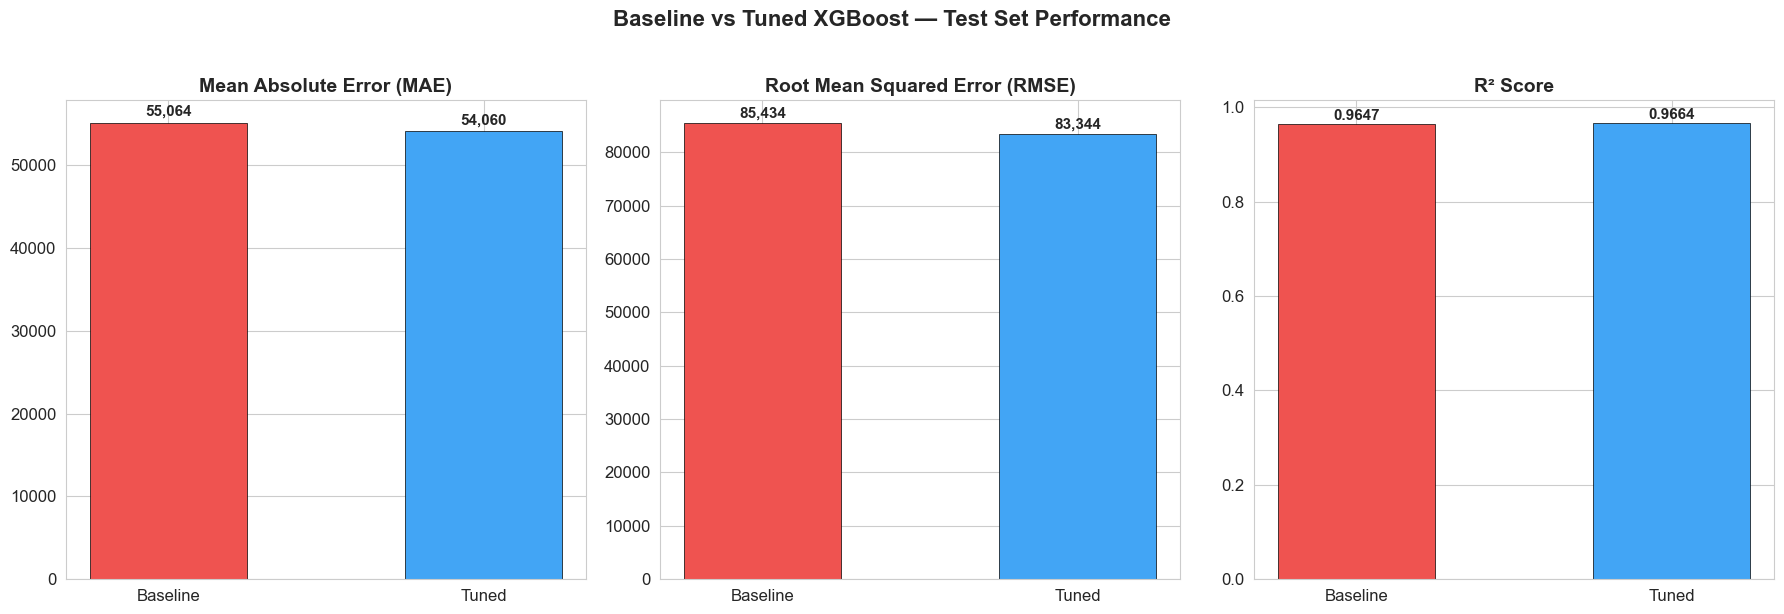

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['Test MAE', 'Test RMSE', 'Test R2']
titles  = ['Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)', 'R\u00b2 Score']
colors_pair = ['#EF5350', '#42A5F5']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    vals = [baseline_results[metric], tuned_results[metric]]
    bars = axes[idx].bar(['Baseline', 'Tuned'], vals, color=colors_pair, 
                         edgecolor='black', linewidth=0.5, width=0.5)
    axes[idx].set_title(title, fontweight='bold')
    
    for bar, v in zip(bars, vals):
        if metric == 'Test R2':
            axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                          f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
        else:
            axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                          f'{v:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Baseline vs Tuned XGBoost \u2014 Test Set Performance', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9.2 · Actual vs Predicted (Baseline vs Tuned)

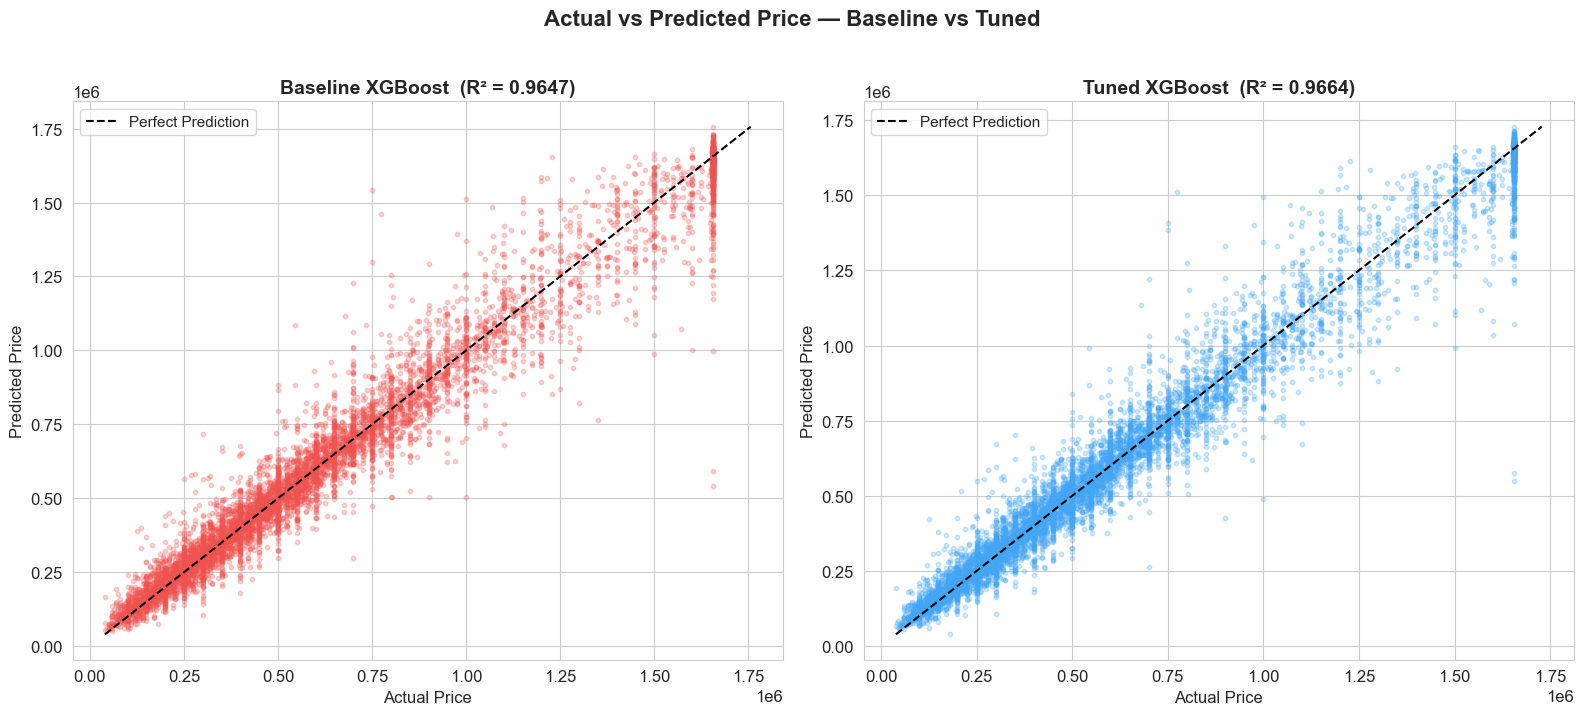

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_data = [
    ('Baseline XGBoost', y_pred_base, '#EF5350'),
    ('Tuned XGBoost', y_pred_tuned, '#42A5F5'),
]

for idx, (name, y_pred, color) in enumerate(plot_data):
    axes[idx].scatter(y_test, y_pred, alpha=0.25, s=10, color=color)
    
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'k--', 
                   linewidth=1.5, label='Perfect Prediction')
    
    r2 = r2_score(y_test, y_pred)
    axes[idx].set_title(f'{name}  (R\u00b2 = {r2:.4f})', fontweight='bold')
    axes[idx].set_xlabel('Actual Price')
    axes[idx].set_ylabel('Predicted Price')
    axes[idx].legend(fontsize=11)

plt.suptitle('Actual vs Predicted Price \u2014 Baseline vs Tuned', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9.3 · Residual Comparison

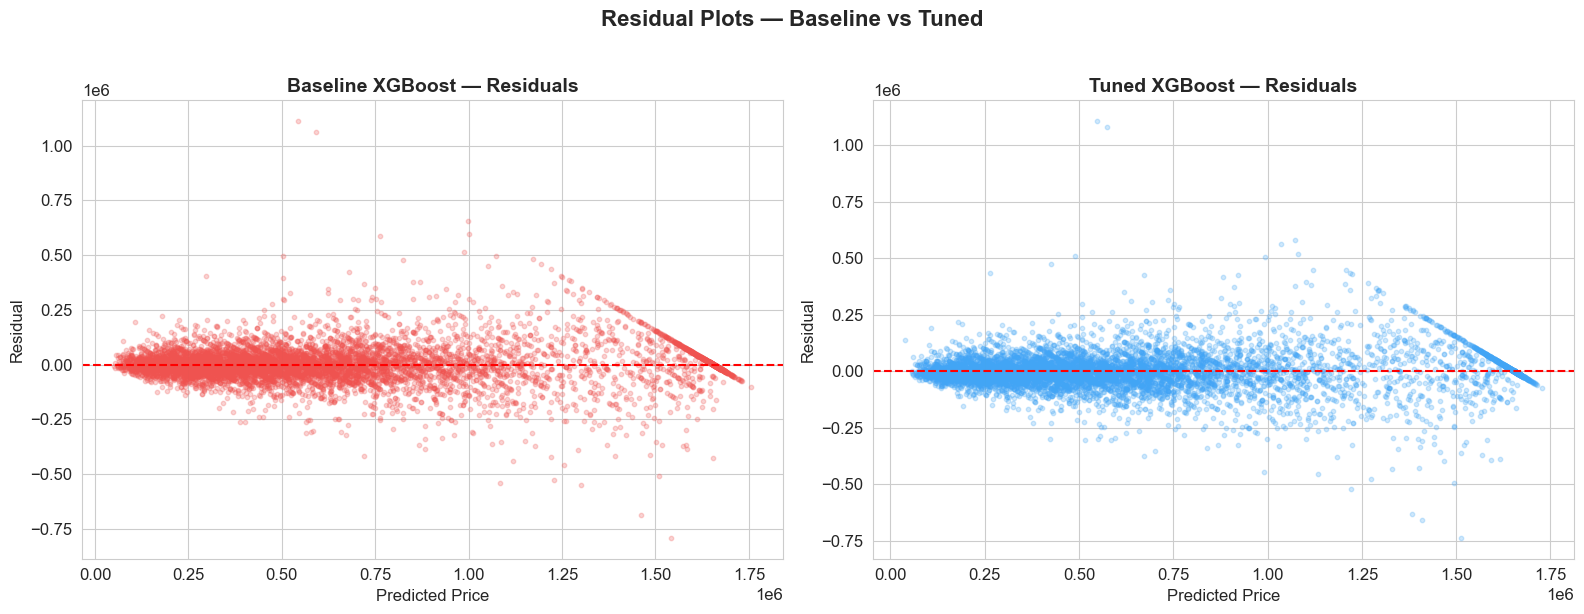

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (name, y_pred, color) in enumerate(plot_data):
    residuals = y_test - y_pred
    axes[idx].scatter(y_pred, residuals, alpha=0.25, s=10, color=color)
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    axes[idx].set_title(f'{name} \u2014 Residuals', fontweight='bold')
    axes[idx].set_xlabel('Predicted Price')
    axes[idx].set_ylabel('Residual')

plt.suptitle('Residual Plots \u2014 Baseline vs Tuned', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9.4 · Error Distribution Comparison

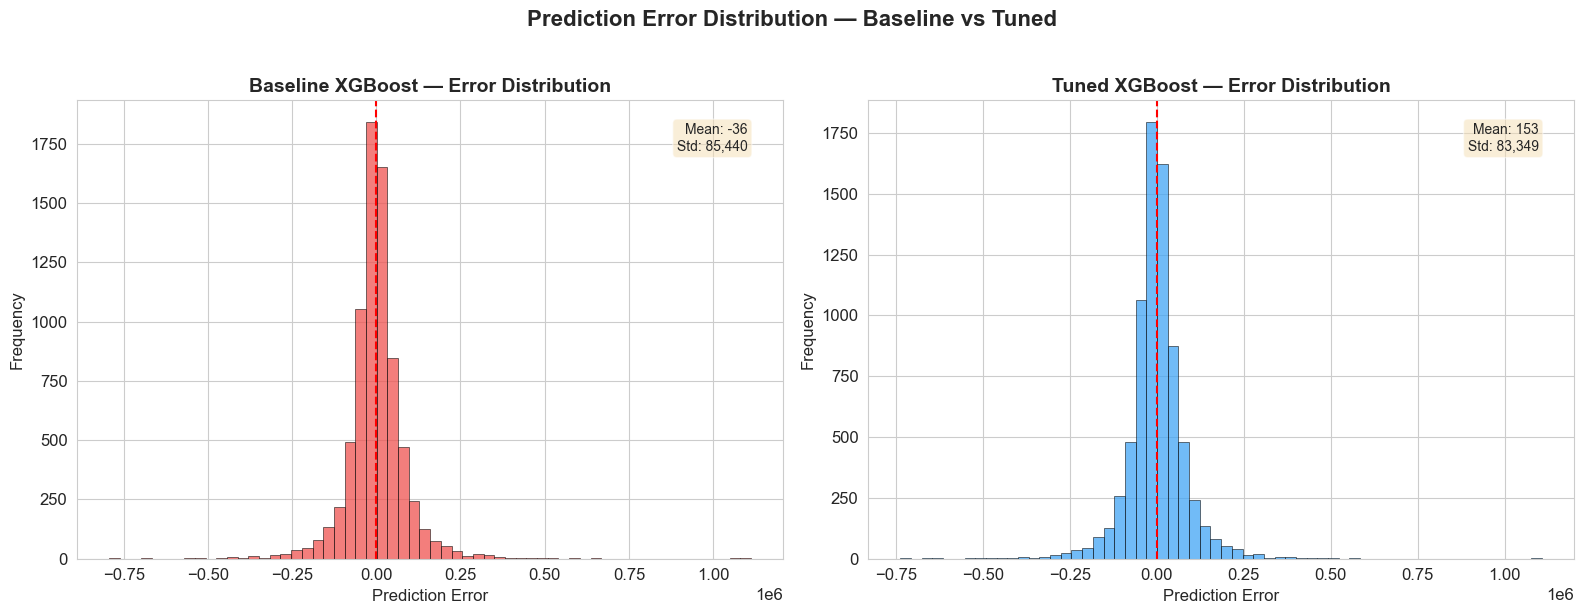

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (name, y_pred, color) in enumerate(plot_data):
    errors = y_test - y_pred
    axes[idx].hist(errors, bins=60, color=color, edgecolor='black', 
                   linewidth=0.5, alpha=0.75)
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
    axes[idx].set_title(f'{name} \u2014 Error Distribution', fontweight='bold')
    axes[idx].set_xlabel('Prediction Error')
    axes[idx].set_ylabel('Frequency')
    
    mean_err = errors.mean()
    std_err  = errors.std()
    textstr  = f'Mean: {mean_err:,.0f}\nStd: {std_err:,.0f}'
    axes[idx].text(0.95, 0.95, textstr, transform=axes[idx].transAxes,
                   fontsize=10, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Prediction Error Distribution \u2014 Baseline vs Tuned', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9.5 · Cross-Validation Score Convergence (Phase 1)

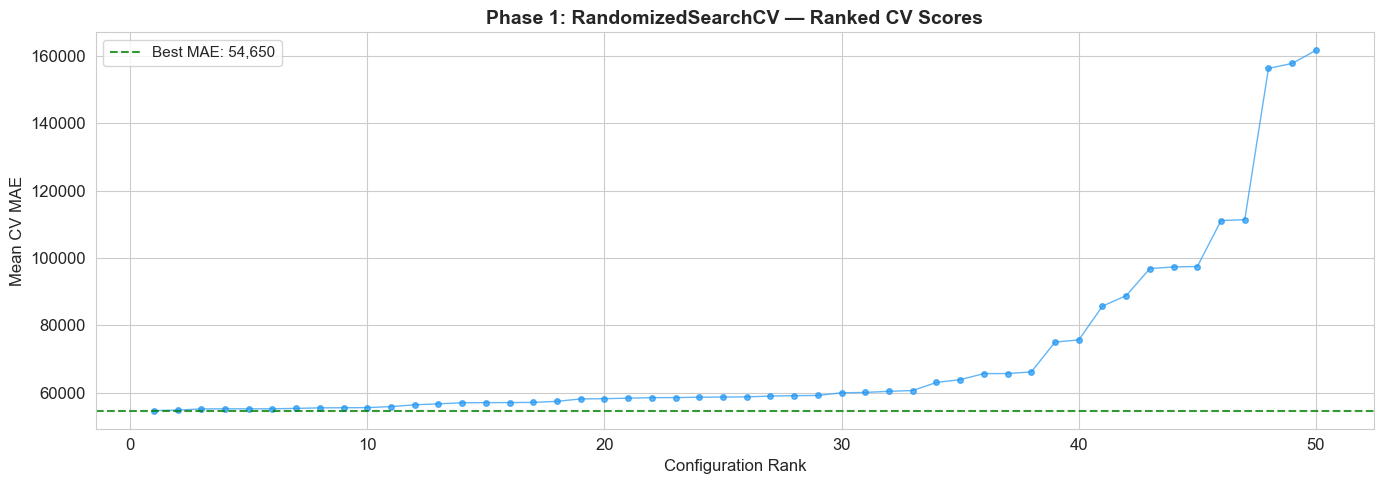

In [34]:
fig, ax = plt.subplots(figsize=(14, 5))

sorted_scores = cv_results_phase1.sort_values('rank_test_score')
maes = -sorted_scores['mean_test_score'].values

ax.plot(range(1, len(maes) + 1), maes, 'o-', markersize=4, alpha=0.7,
        color='#2196F3', linewidth=1)
ax.axhline(y=maes[0], color='green', linestyle='--', linewidth=1.5, 
           label=f'Best MAE: {maes[0]:,.0f}', alpha=0.8)
ax.set_xlabel('Configuration Rank')
ax.set_ylabel('Mean CV MAE')
ax.set_title('Phase 1: RandomizedSearchCV \u2014 Ranked CV Scores', fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 10 · Feature Importance (Tuned Model)

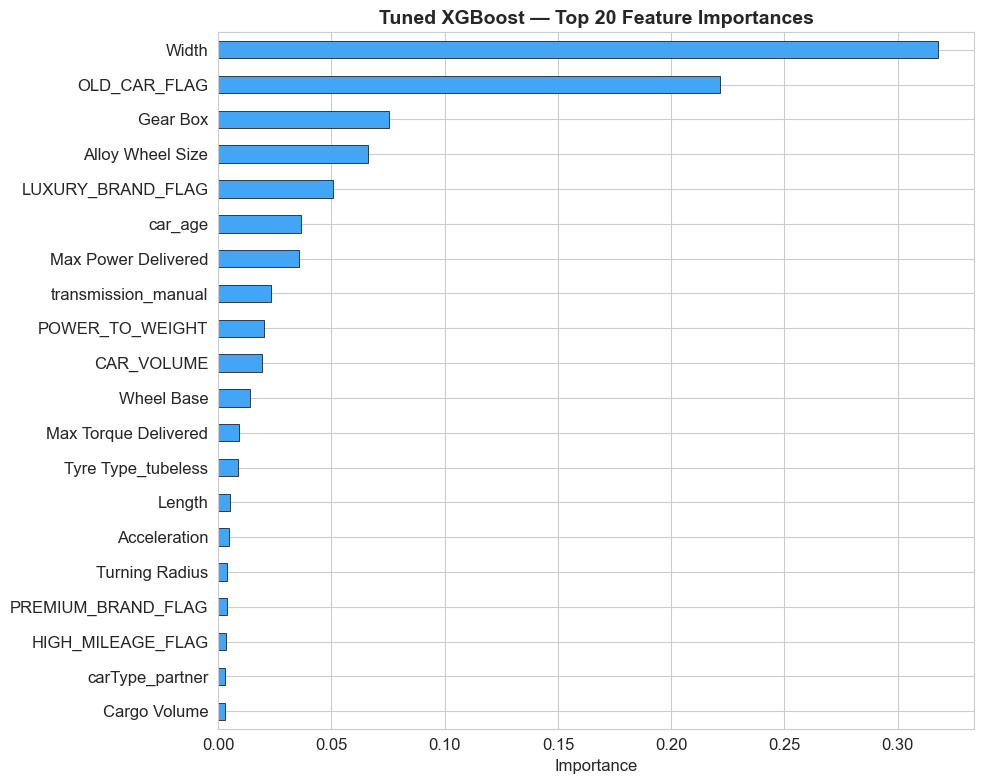

In [35]:
tuned_importance = pd.Series(tuned_xgb.feature_importances_, index=X.columns)
top20 = tuned_importance.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.sort_values().plot(kind='barh', ax=ax, color='#42A5F5', 
                          edgecolor='black', linewidth=0.5)
ax.set_title('Tuned XGBoost \u2014 Top 20 Feature Importances', fontweight='bold', fontsize=14)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 11 · Cross-Validation on Final Tuned Model

5-fold CV on the **full training set** to get robust performance estimates.

In [36]:
print('Running 5-fold Cross-Validation on the tuned model...')
print()

cv_mae = cross_val_score(tuned_xgb, X_train, y_train, 
                         cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_rmse = cross_val_score(tuned_xgb, X_train, y_train, 
                          cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_r2 = cross_val_score(tuned_xgb, X_train, y_train, 
                        cv=5, scoring='r2', n_jobs=-1)

print('=' * 60)
print('  5-FOLD CROSS-VALIDATION RESULTS (Tuned XGBoost)')
print('=' * 60)
print(f'  MAE  : {-cv_mae.mean():>12,.2f}  (+/- {cv_mae.std():,.2f})')
print(f'  RMSE : {-cv_rmse.mean():>12,.2f}  (+/- {cv_rmse.std():,.2f})')
print(f'  R2   : {cv_r2.mean():>12.4f}  (+/- {cv_r2.std():.4f})')
print('=' * 60)
print()
print('Per-fold R2 scores:', [f'{s:.4f}' for s in cv_r2])

Running 5-fold Cross-Validation on the tuned model...

  5-FOLD CROSS-VALIDATION RESULTS (Tuned XGBoost)
  MAE  :    53,349.31  (+/- 665.11)
  RMSE :    83,592.89  (+/- 1,512.82)
  R2   :       0.9661  (+/- 0.0010)

Per-fold R2 scores: ['0.9671', '0.9645', '0.9659', '0.9656', '0.9672']


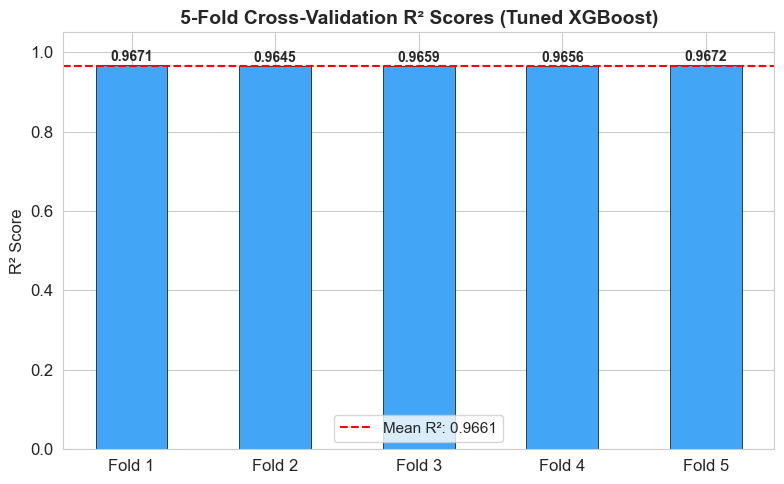

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))

folds = [f'Fold {i+1}' for i in range(5)]
bars = ax.bar(folds, cv_r2, color='#42A5F5', edgecolor='black', 
              linewidth=0.5, width=0.5)
ax.axhline(y=cv_r2.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean R\u00b2: {cv_r2.mean():.4f}')

for bar, v in zip(bars, cv_r2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('R\u00b2 Score')
ax.set_title('5-Fold Cross-Validation R\u00b2 Scores (Tuned XGBoost)', fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 12 · Final Summary

In [38]:
print('=' * 70)
print('  HYPERPARAMETER TUNING - FINAL SUMMARY')
print('=' * 70)
print()
print('  Best Hyperparameters:')
for param, value in sorted(best_params_final.items()):
    tag = '[TUNED]' if param in top_params else '[FIXED]'
    print(f'    {tag:8s} {param:20s} : {value}')
print()
print('  Test Set Performance:')
print(f'    {"Metric":15s} {"Baseline":>12s} {"Tuned":>12s} {"Change %":>10s}')
print(f'    {"-"*15} {"-"*12} {"-"*12} {"-"*10}')

for metric in ['Test MAE', 'Test RMSE', 'Test R2']:
    b = baseline_results[metric]
    t = tuned_results[metric]
    pct = ((t - b) / abs(b)) * 100
    if metric == 'Test R2':
        print(f'    {metric:15s} {b:>12.4f} {t:>12.4f} {pct:>+9.2f}%')
    else:
        print(f'    {metric:15s} {b:>12,.0f} {t:>12,.0f} {pct:>+9.2f}%')

print()
print('  5-Fold CV R2: {:.4f} (+/- {:.4f})'.format(cv_r2.mean(), cv_r2.std()))
print()
print('=' * 70)

  HYPERPARAMETER TUNING - FINAL SUMMARY

  Best Hyperparameters:
    [FIXED]  colsample_bytree     : 0.9
    [FIXED]  gamma                : 1.0
    [TUNED]  learning_rate        : 0.03
    [FIXED]  max_depth            : 8
    [TUNED]  min_child_weight     : 1
    [TUNED]  n_estimators         : 500
    [FIXED]  subsample            : 0.7

  Test Set Performance:
    Metric              Baseline        Tuned   Change %
    --------------- ------------ ------------ ----------
    Test MAE              55,064       54,060     -1.82%
    Test RMSE             85,434       83,344     -2.45%
    Test R2               0.9647       0.9664     +0.18%

  5-Fold CV R2: 0.9661 (+/- 0.0010)



---
**Next Steps:**
- Experiment with `reg_alpha` and `reg_lambda` regularization parameters
- Try early stopping with a validation set
- Explore feature selection to reduce dimensionality
- Consider stacking/blending with other strong models
- Deploy the tuned model for inference
---